
# Lab_4: FDM-capacitor

### Potential and Electric field from a capacitor

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:

\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}
\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}

However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

* Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

* Compute numerically (use finite difference method) the electric field.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" width="500" height="300" />

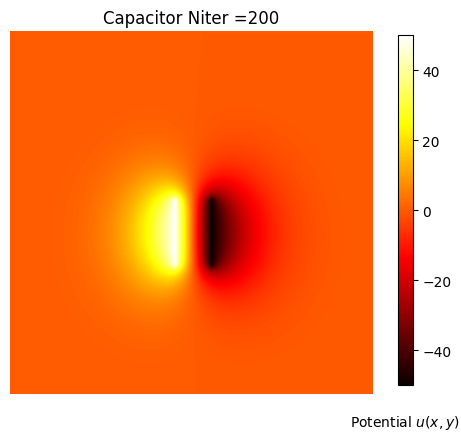

In [ ]:
# let's construc you own rutine. As an example:
from capacitor import capacitor_df #my rutine

# Plot imshow
Niter = 200
V = capacitor_df(Niter)
fig, ax = plt.subplots(figsize=(5,5) )
im = ax.imshow(V.copy(),cmap="hot",interpolation="bilinear",)
ax.set_axis_off()
ax.set_title('Capacitor Niter =%.1d'%Niter)

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("Potential $u(x,y)$", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

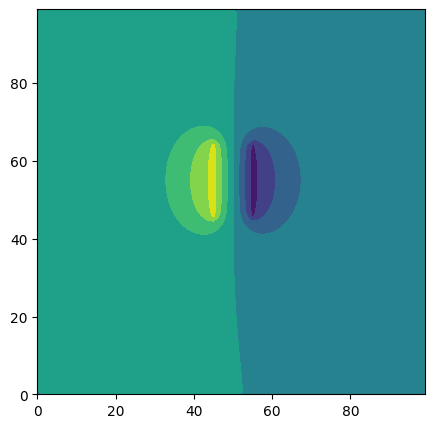

In [ ]:
plt.subplots(figsize=(5,5) )
plt.contourf(V)
plt.show()

Resolviendo Laplace con placas verticales...
Iter 1000, cambio=5.84e-04
Iter 2000, cambio=7.04e-06
Convergió en 2564 iteraciones, cambio final 9.98e-07


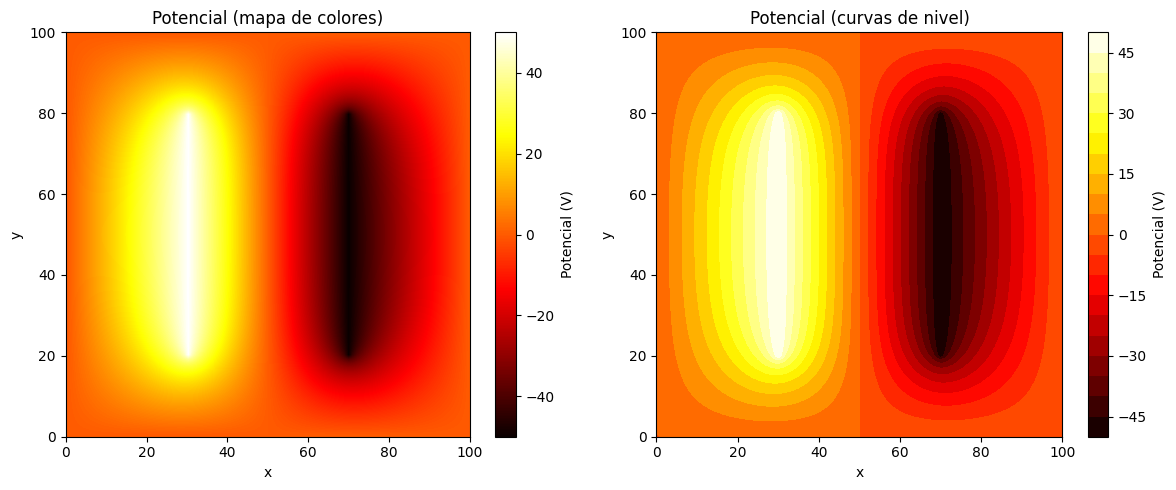

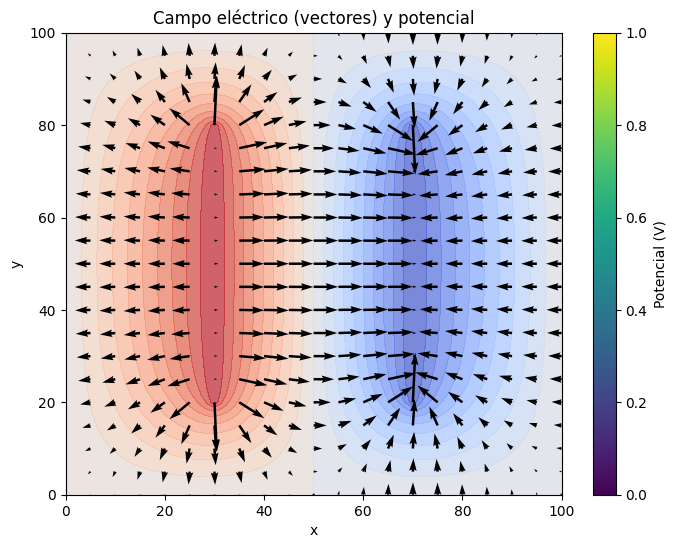

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Parámetros del problema (placas verticales)
# ------------------------------------------------------------
Lx = 100.0          # ancho del dominio
Ly = 100.0          # alto del dominio
Nx = 101            # puntos en x
Ny = 101            # puntos en y
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)

V_izq = 50.0        # potencial en placa izquierda
V_der = -50.0       # potencial en placa derecha

# Posición de las placas (en índices)
# Placa izquierda: columna i_izq, desde j_inf hasta j_sup
i_izq = 30          # columna de la placa izquierda
i_der = 70          # columna de la placa derecha
j_inf = 20          # fila inferior de las placas (y baja)
j_sup = 80          # fila superior de las placas (y alta)

# ------------------------------------------------------------
# Crear malla de coordenadas
# ------------------------------------------------------------
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing='ij')

# ------------------------------------------------------------
# Inicializar potencial y fijar condiciones de contorno
# ------------------------------------------------------------
phi = np.zeros((Nx, Ny))

# Bordes del dominio a cero (ya están en cero)
# Asignar potencial a las placas (verticales)
phi[i_izq, j_inf:j_sup+1] = V_izq   # placa izquierda
phi[i_der, j_inf:j_sup+1] = V_der   # placa derecha

# ------------------------------------------------------------
#  con tolerancia
# ------------------------------------------------------------
tolerancia = 1e-6
max_iter = 20000
cambio = 1.0
iteracion = 0

print("Resolviendo Laplace con placas verticales...")
while cambio > tolerancia and iteracion < max_iter:
    phi_old = phi.copy()
    for i in range(1, Nx-1):
        for j in range(1, Ny-1):
            # Si el punto pertenece a alguna placa, no actualizar
            if (i == i_izq and j >= j_inf and j <= j_sup) or \
               (i == i_der and j >= j_inf and j <= j_sup):
                continue
            phi[i, j] = 0.25 * (phi[i+1, j] + phi[i-1, j] +
                                phi[i, j+1] + phi[i, j-1])
    cambio = np.max(np.abs(phi - phi_old))
    iteracion += 1
    if iteracion % 1000 == 0:
        print(f'Iter {iteracion}, cambio={cambio:.2e}')
print(f'Convergió en {iteracion} iteraciones, cambio final {cambio:.2e}')

# ------------------------------------------------------------
# Campo eléctrico (E = -grad phi)
# ------------------------------------------------------------
Ex = np.zeros((Nx, Ny))
Ey = np.zeros((Nx, Ny))
for i in range(1, Nx-1):
    for j in range(1, Ny-1):
        Ex[i, j] = -(phi[i+1, j] - phi[i-1, j]) / (2*dx)
        Ey[i, j] = -(phi[i, j+1] - phi[i, j-1]) / (2*dy)
# Rellenar bordes
Ex[0,:] = Ex[1,:]; Ex[-1,:] = Ex[-2,:]; Ex[:,0] = Ex[:,1]; Ex[:,-1] = Ex[:,-2]
Ey[0,:] = Ey[1,:]; Ey[-1,:] = Ey[-2,:]; Ey[:,0] = Ey[:,1]; Ey[:,-1] = Ey[:,-2]

# ------------------------------------------------------------
# Visualización
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# imshow
im = axes[0].imshow(phi.T, origin='lower', extent=[0, Lx, 0, Ly],
                    cmap='hot', interpolation='bilinear')
axes[0].set_title('Potencial (mapa de colores)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
fig.colorbar(im, ax=axes[0], label='Potencial (V)')

# contourf
cont = axes[1].contourf(X, Y, phi, levels=20, cmap='hot')
axes[1].set_title('Potencial (curvas de nivel)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
fig.colorbar(cont, ax=axes[1], label='Potencial (V)')
plt.tight_layout()
plt.show()

# Campo vectorial
skip = 5
X_sub = X[::skip, ::skip]
Y_sub = Y[::skip, ::skip]
Ex_sub = Ex[::skip, ::skip]
Ey_sub = Ey[::skip, ::skip]

plt.figure(figsize=(8,6))
plt.contourf(X, Y, phi, levels=20, cmap='coolwarm', alpha=0.7)
plt.quiver(X_sub, Y_sub, Ex_sub, Ey_sub, color='black', scale=50, width=0.005)
plt.title('Campo eléctrico (vectores) y potencial')
plt.xlabel('x'); plt.ylabel('y')
plt.colorbar(label='Potencial (V)')
plt.show()